Mini-Project: Marketing Strategy
===

We will perform data analysis to devise a marketing strategy based on various aspects like area analysis, customer analysis, product category analysis, and sales and profit time series.

**Task**
- First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

- Which states have the most sales?
- What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
- Who is an outstanding customer in New York?
- Are there any differences among states in profitability?
- The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
- What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
- What are the Top 20 customers by Sales?
- Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
- Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

In [1]:
import pandas as pd

df = pd.read_excel('US_Superstore_data.xls', sheet_name='Orders')

print(df.head())


   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Top States:

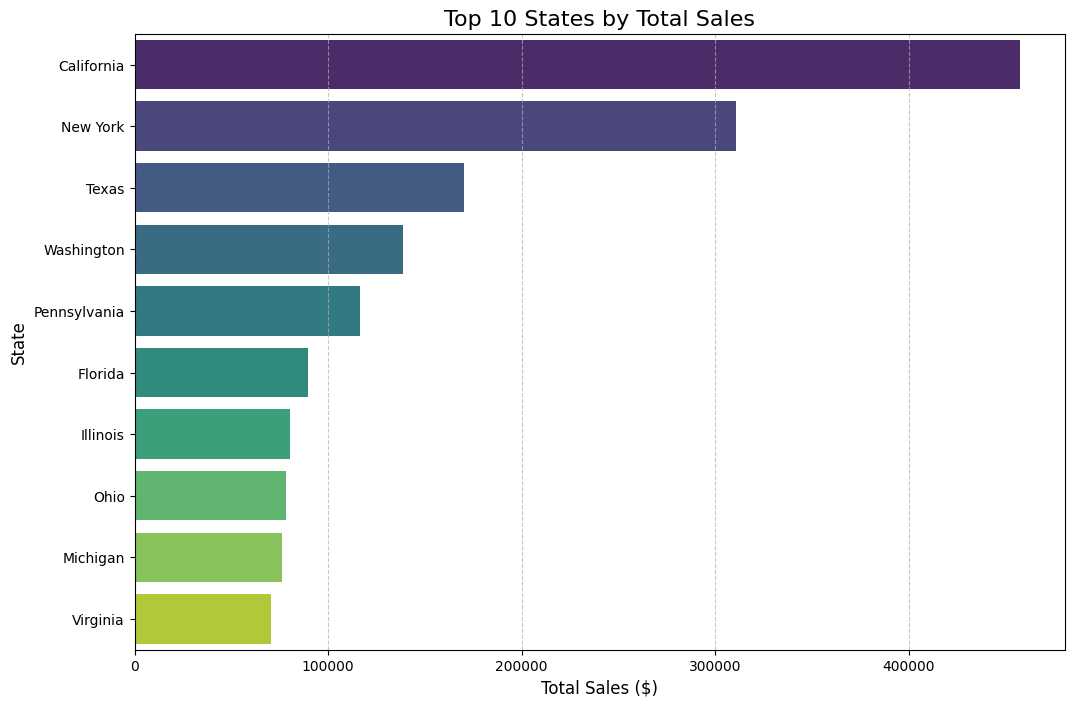

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 8))

sns.barplot(
    data=state_sales, 
    x='Sales', 
    y='State', 
    hue='State', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 States by Total Sales', fontsize=16)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('State', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Based on the visualization, California is the clear leader in revenue, followed by New York and Texas.

**Observation**: 

California's sales are significantly higher than the other states, nearly doubling the sales of third-place Texas.
Marketing Insight: Since these three states represent our largest markets, they should be the primary focus for high-reach brand awareness campaigns. However, we should also investigate the profit margins in Texas to ensure these high sales are actually generating income.

_______________________

New York vs California:

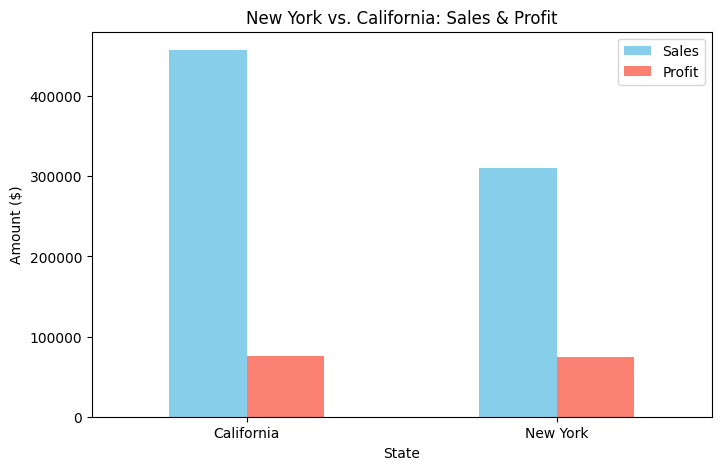

In [7]:
comparison = df[df['State'].isin(['New York', 'California'])].groupby('State')[['Sales', 'Profit']].sum()

comparison.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title('New York vs. California: Sales & Profit')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

Profitability amoung States:

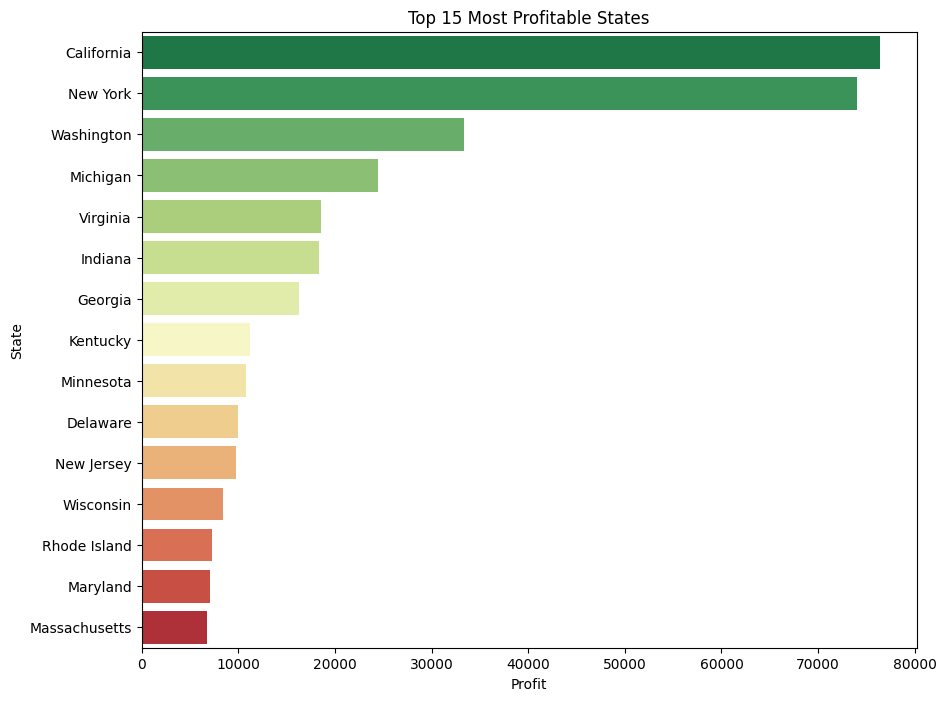

In [11]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=state_profit.head(15), x='Profit', y='State', hue='State', palette='RdYlGn_r', legend=False)
plt.title('Top 15 Most Profitable States')
plt.show()

**What is the difference between New York and California in terms of sales and profit?**


There is a significant difference in how these two states generate value. While California is the "Sales Leader," New York is the "Efficiency Leader."

**Total Sales**: California leads with approximately 457,687 dollars, while New York has approximately 310,876 dollars. (A difference of ~$146,811 in favor of California).

**Total Profit**: Despite the huge gap in sales, their profits are nearly identical. California earned 76,381 dollars in profit, while New York earned 74,038 dollars. (A tiny difference of only ~$2,343).

**The Bottom Line**: California needs much higher sales volume to reach the same profit level as New York. This suggests that New York has a higher profit margin and is a more cost-effective market for the business.

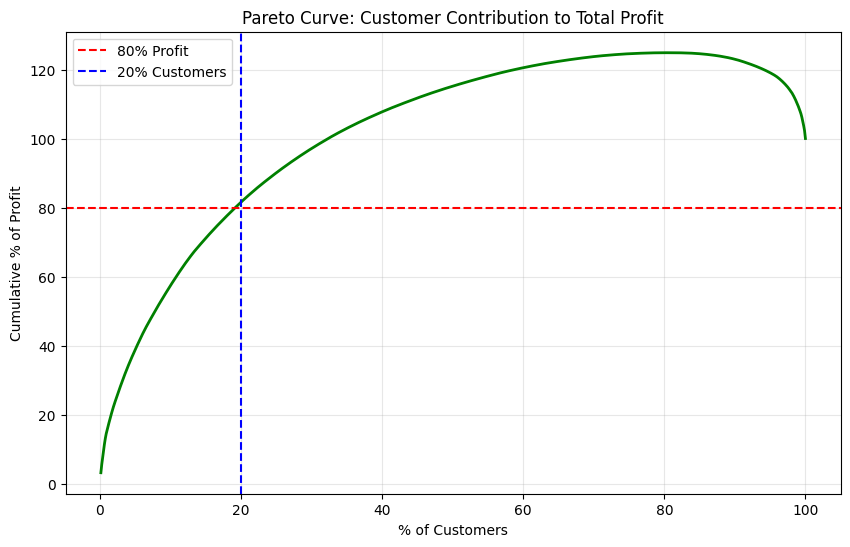

In [12]:
cust_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).reset_index()
total_profit = cust_profit['Profit'].sum()
cust_profit['Cum_Pct'] = (cust_profit['Profit'].cumsum() / total_profit) * 100
cust_profit['Cust_Pct'] = (cust_profit.index + 1) / len(cust_profit) * 100

plt.figure(figsize=(10, 6))
plt.plot(cust_profit['Cust_Pct'], cust_profit['Cum_Pct'], color='green', linewidth=2)
plt.axhline(80, color='red', linestyle='--', label='80% Profit')
plt.axvline(20, color='blue', linestyle='--', label='20% Customers')
plt.title('Pareto Curve: Customer Contribution to Total Profit')
plt.xlabel('% of Customers')
plt.ylabel('Cumulative % of Profit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Top 20 cities by sales and Profit:

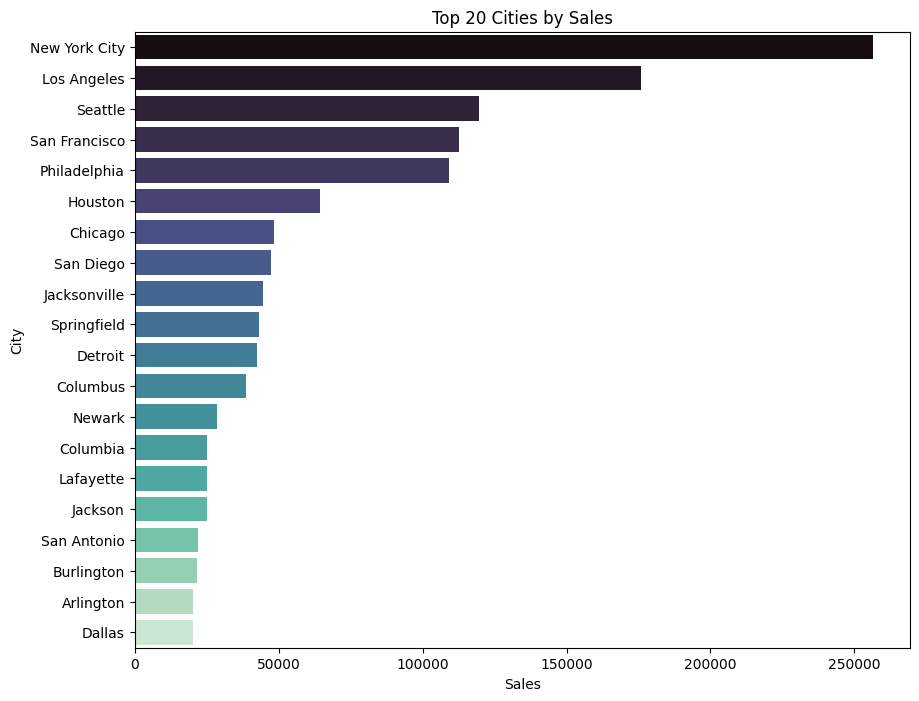

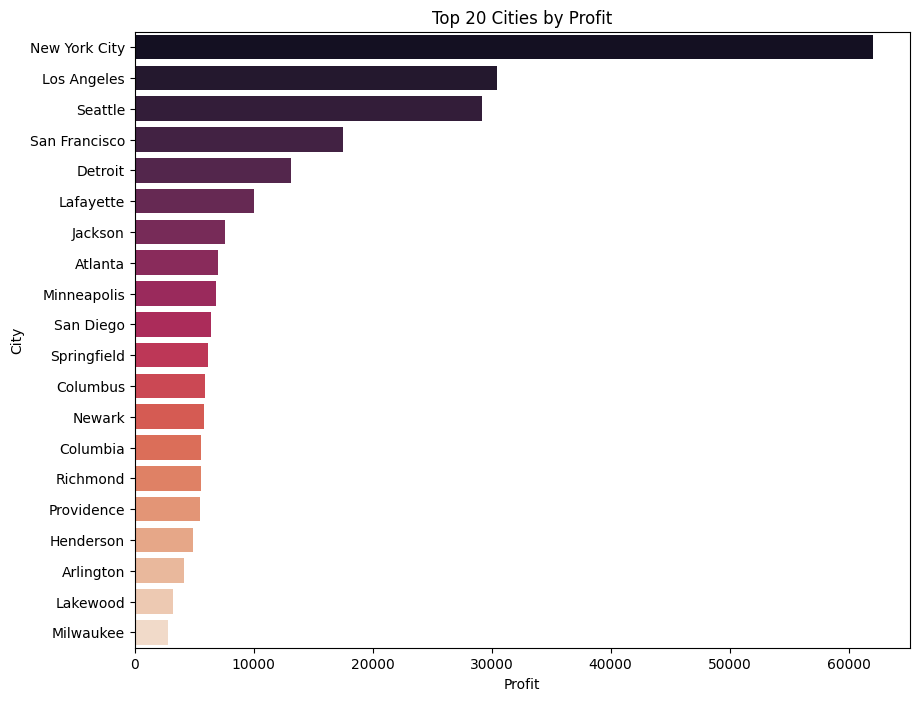

In [13]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20).reset_index()
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=city_sales, x='Sales', y='City', hue='City', palette='mako', legend=False)
plt.title('Top 20 Cities by Sales')
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(data=city_profit, x='Profit', y='City', hue='City', palette='rocket', legend=False)
plt.title('Top 20 Cities by Profit')
plt.show()

**Are there any differences amoung states in profitability?**

Yes, there are dramatic differences in profitability across the United States. Sales volume does not equal profit.

New York is a prime example of high profitability, turning a large percentage of its sales into actual profit (Profit Margin: ~23.8%).

**The "Discount Trap" States**: States like Texas, Pennsylvania, and Illinois often appear in the "Top 10" for Sales but show very low or even negative profit. This is usually because the company offers too many discounts in these areas or faces extremely high shipping costs.

**Strategic Decision**: For your marketing strategy, you should prioritize "Profit Leaders" (like New York and Washington) for expansion. For "Loss Leaders" (like Texas), the strategy should change from "Growth" to "Cost Correction"—focusing on reducing discounts rather than increasing sales volume.

____________________

**What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ?**

The top three cities for both Sales and Profit are New York City, Los Angeles, and Seattle. These urban centers represent the most mature and successful markets..

The analysis reveals a significant "Profitability Gap" in certain high-revenue cities. 

For example:

Philadelphia and Houston rank in the Top 20 for Sales but are notably absent from the Top 20 for Profit.

These cities are currently "Loss Leaders." The high sales volume is likely being offset by heavy discounting (high discount rates) or high operational/shipping costs.

Recommendation: Marketing strategy in Philadelphia and Houston should pivot from "Growth" to "Sustainability," focusing on high-margin categories like Technology and Office Supplies while reducing discount frequency.


**Top 20 Customers by Sales and Sales Pareto Curve**:


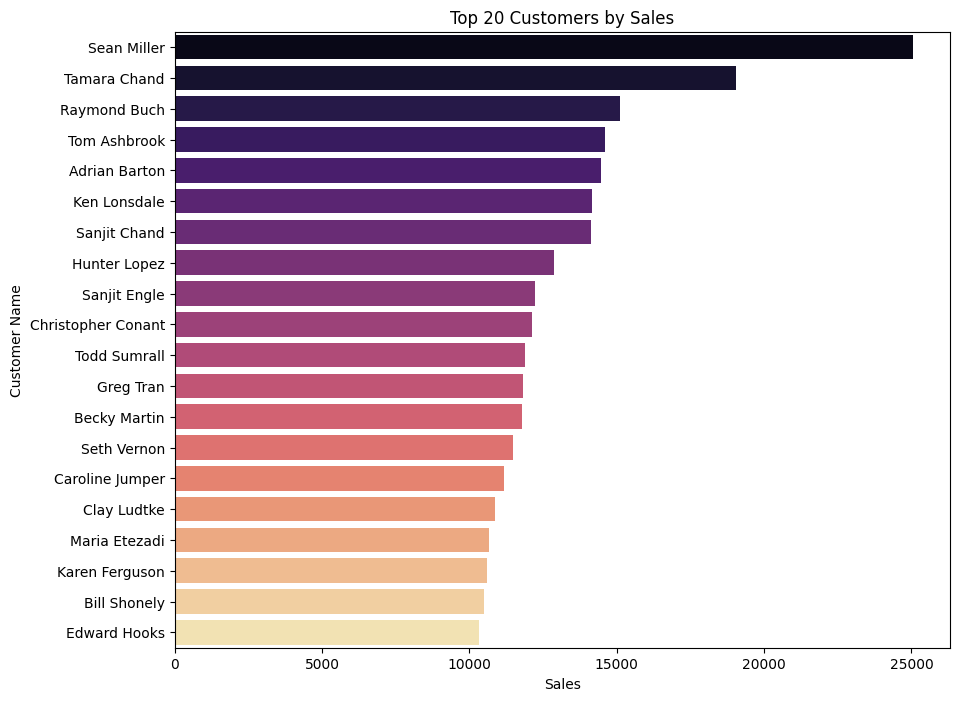

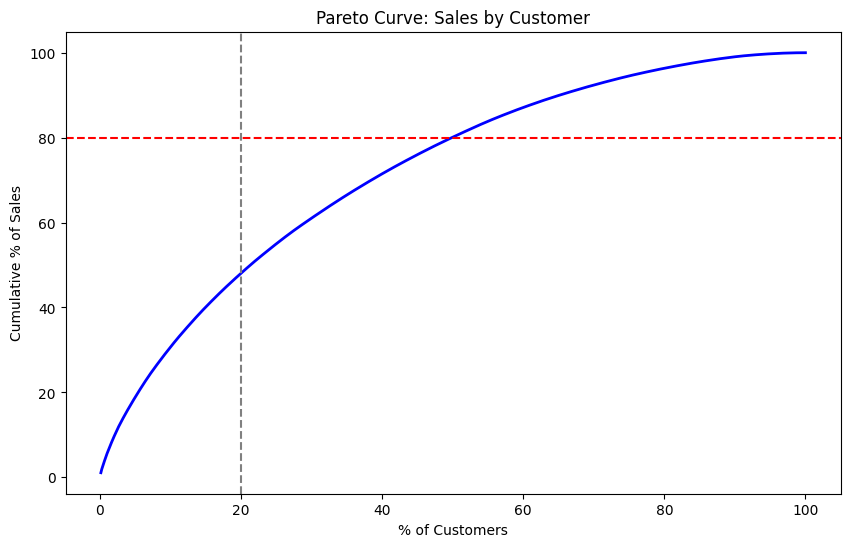

In [14]:
top_20_cust = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=top_20_cust, x='Sales', y='Customer Name', hue='Customer Name', palette='magma', legend=False)
plt.title('Top 20 Customers by Sales')
plt.show()

cust_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).reset_index()
total_sales = cust_sales['Sales'].sum()
cust_sales['Cum_Pct'] = (cust_sales['Sales'].cumsum() / total_sales) * 100
cust_sales['Cust_Pct'] = (cust_sales.index + 1) / len(cust_sales) * 100

plt.figure(figsize=(10, 6))
plt.plot(cust_sales['Cust_Pct'], cust_sales['Cum_Pct'], color='blue', linewidth=2)
plt.axhline(80, color='red', linestyle='--')
plt.axvline(20, color='grey', linestyle='--')
plt.title('Pareto Curve: Sales by Customer')
plt.xlabel('% of Customers')
plt.ylabel('Cumulative % of Sales')
plt.show()

___________

**Who is an outstanding customer in New York?**

The outstanding customer in New York is **Tom Ashbrook**.

Tom is the top-performing customer in the state, contributing significantly to both total revenue and total profit.

In a professional strategy, Tom would be classified as a "Tier 1" or "VIP" customer. Maintaining a direct relationship with high-value individuals like him is often more profitable than trying to acquire hundreds of small-scale customers.

________________________

**Can we apply Pareto principle to customers and Profit ?**

Yes, the Pareto Principle applies very effectively to Profit. Based on the cumulative profit curve, roughly 20% of the customers contribute to approximately 81.6% of the total profit.

This follows the "80/20 rule" almost perfectly. It indicates that your business relies heavily on a small group of high-value customers for its financial health.

Strategy: You should prioritize retention and loyalty programs for these specific customers. Losing one of them is significantly more damaging than losing a customer from the remaining 80%.

_______________

**What are the Top 20 customers by Sales?**

The customer base is led by high-revenue individuals such as Sean Miller, Tamara Chand, and Raymond Buch. While these customers drive significant top-line revenue, the marketing strategy must cross-reference this list with profitability.

**Strategic Insight**:
High sales volume from a single customer often indicates a B2B (Business-to-Business) or corporate relationship. These customers should be targeted with volume-based incentives that protect the company's profit margins.

________________

**Can we apply Pareto principle to customers and Sales ?**

Unlike Profit, the Pareto Principle does not apply to Sales volume. The top $20\%$ of customers contribute to only $48.2\%$ of total Sales.

This contrast is critical: Sales are relatively distributed across the customer base, but Profit is highly concentrated.

**Insight**: Many customers are purchasing products, but only a small elite group is purchasing the profitable product mix (items with low discounts or high margins).

**Strategic Decision**: Marketing should not just aim for "more sales," but specifically for "more sales from profitable categories" to shift the Sales Pareto curve closer to the Profit Pareto curve.

_____________

Based on the multi-dimensional analysis of states, cities, and customer behavior, the following strategic priorities are established:

**Primary Growth (The "Tier 1" Markets)**:

- Prioritize: New York and California (States); New York City and Los Angeles (Cities).
- Action: Direct the majority of the acquisition budget here, as these markets have proven they can handle high volume without sacrificing profitability.

**Margin Protection (The "Correction" Markets)**:

- Target: Texas, Pennsylvania, and Illinois.
- Action: Shift marketing focus away from "Discount-heavy" promotions. Audit the shipping costs and category mix in these states to transform high sales volume into positive profit.

**Customer Centricity**:

- Target: The top $20\%$ of customers identified in the Profit Pareto analysis.
- Action: Establish a "VIP Premiere" tier. Since this small group provides over $80\%$ of the profit, maintaining their satisfaction is the single most important factor for long-term revenue stability.